In [220]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [221]:
#Loading dataset
df=pd.read_csv('student_performance_dataset.csv')

In [222]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


# EDA

In [223]:
df.shape

(708, 10)

In [224]:
df.columns

Index(['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'Parental_Education_Level',
       'Internet_Access_at_Home', 'Extracurricular_Activities',
       'Final_Exam_Score', 'Pass_Fail'],
      dtype='object')

In [225]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [226]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [227]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0
Pass_Fail,0


In [228]:
df.drop_duplicates(inplace=True)

In [229]:
df.shape

(500, 10)

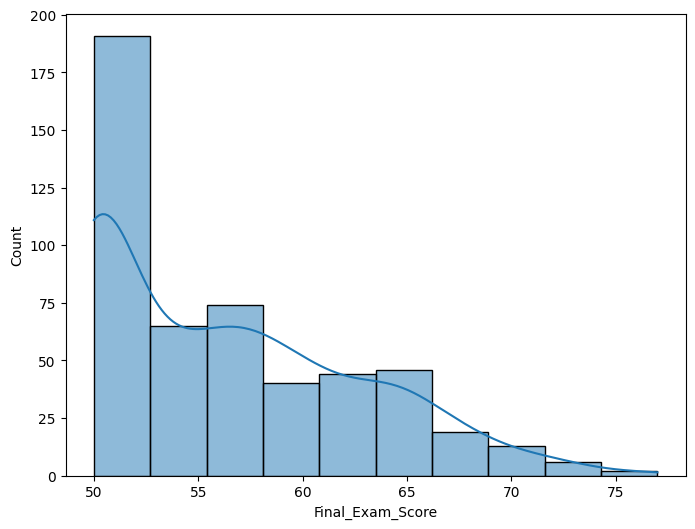

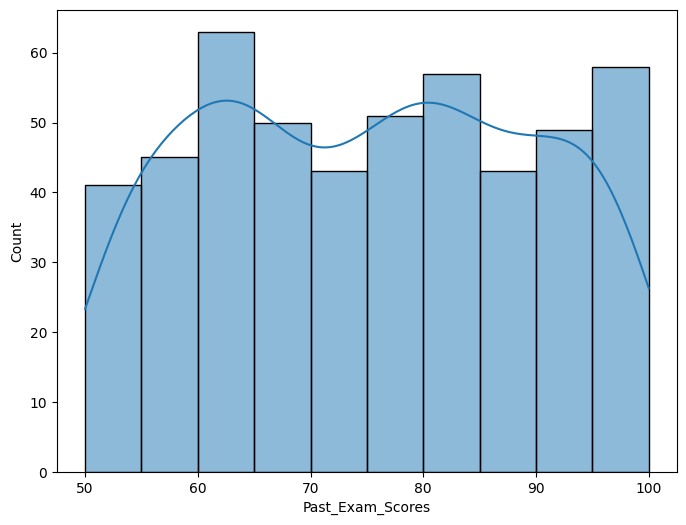

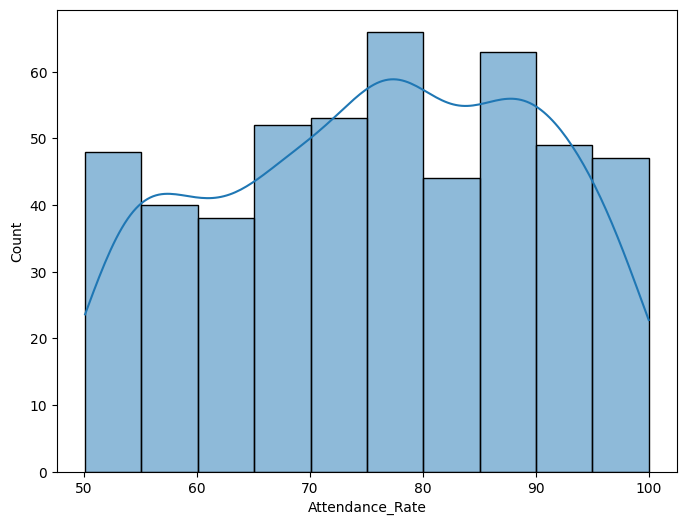

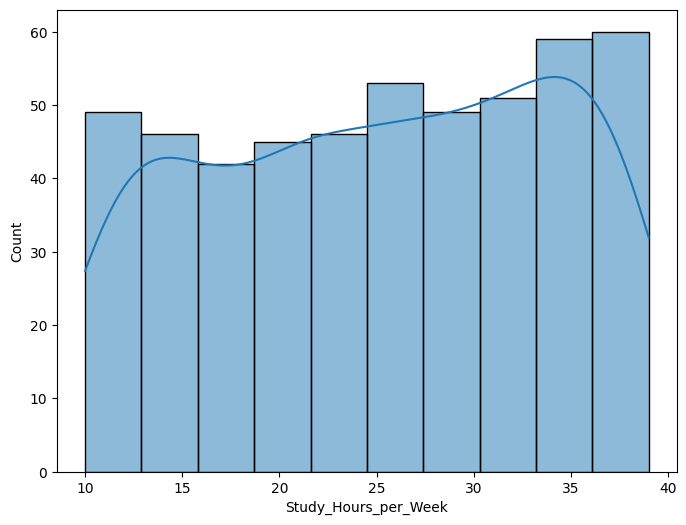

In [230]:
numeric_columns=['Final_Exam_Score','Past_Exam_Scores','Attendance_Rate','Study_Hours_per_Week'];
for col in numeric_columns:
  plt.figure(figsize=(8,6));
  sns.histplot(df[col],kde=True)

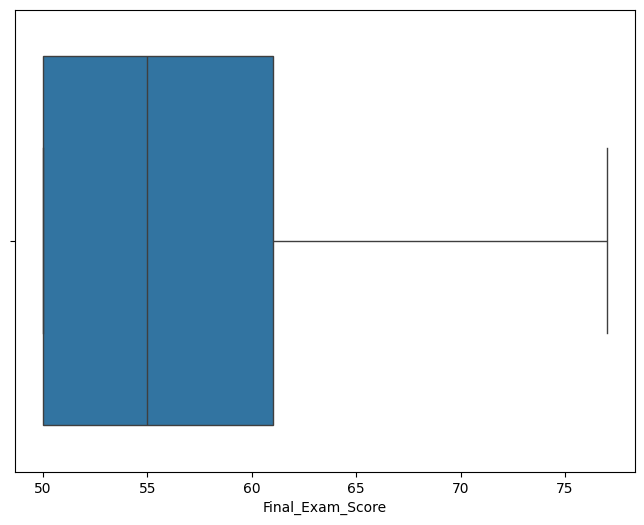

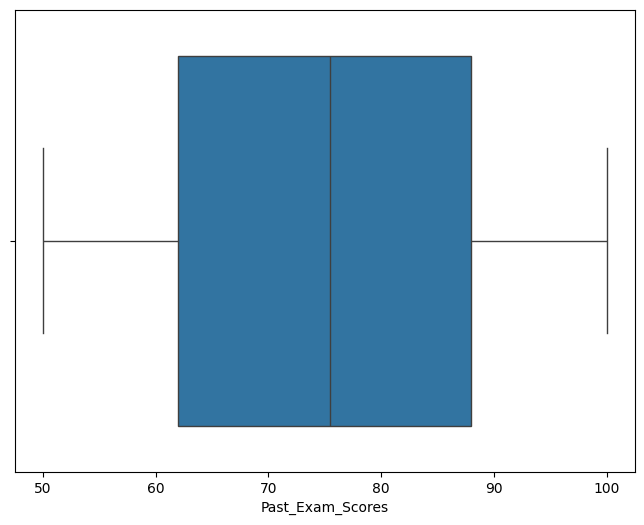

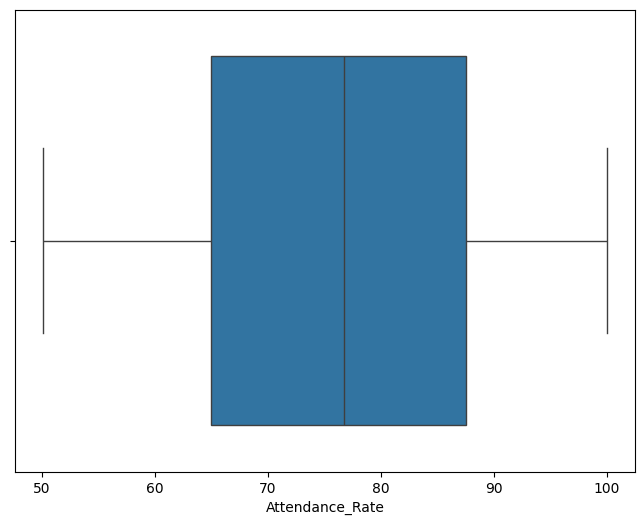

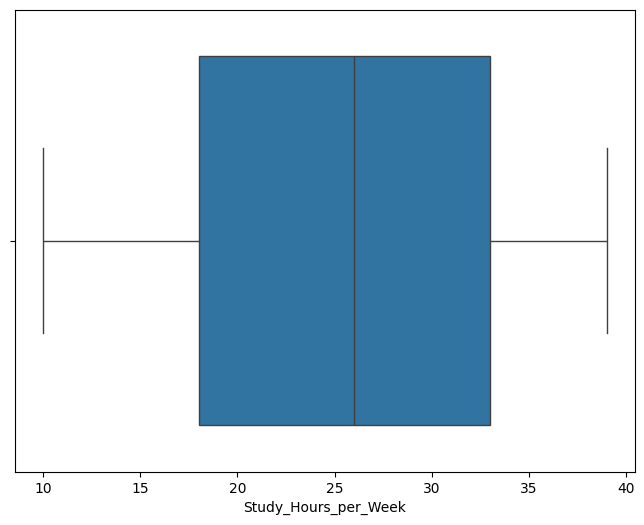

In [231]:
numeric_columns=['Final_Exam_Score','Past_Exam_Scores','Attendance_Rate','Study_Hours_per_Week'];
for col in numeric_columns:
  plt.figure(figsize=(8,6));
  sns.boxplot(x=df[col])

In [232]:
df.columns

Index(['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'Parental_Education_Level',
       'Internet_Access_at_Home', 'Extracurricular_Activities',
       'Final_Exam_Score', 'Pass_Fail'],
      dtype='object')

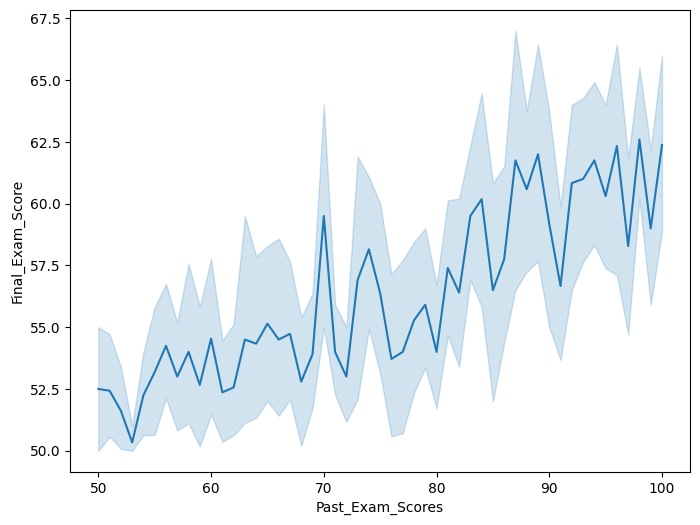

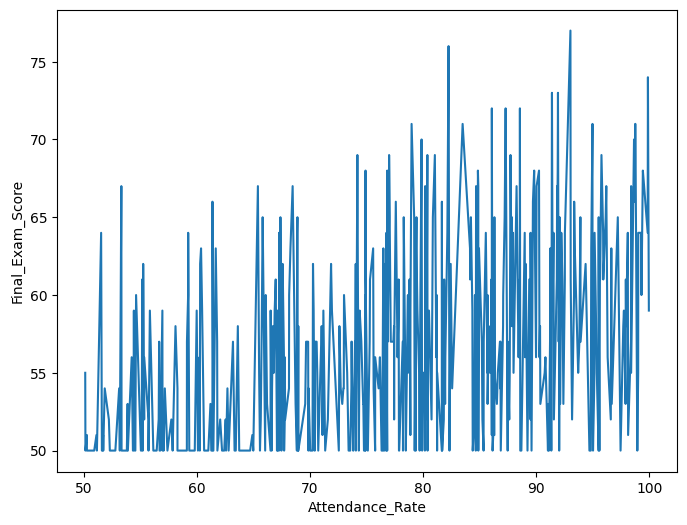

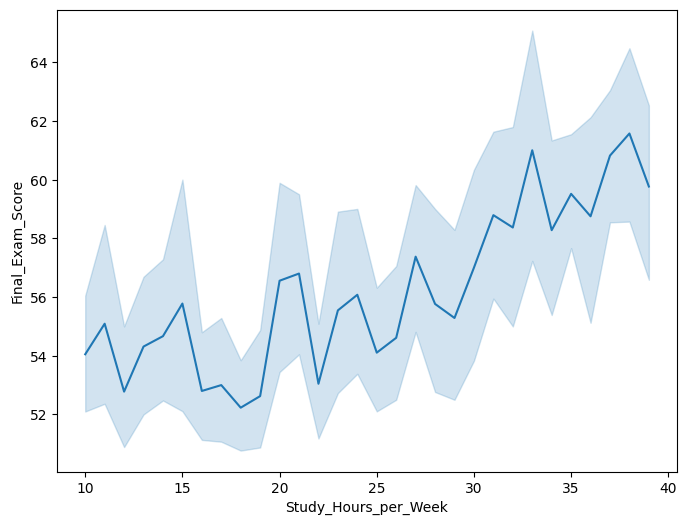

In [233]:
numeric_columns=['Past_Exam_Scores','Attendance_Rate','Study_Hours_per_Week'];
for col in numeric_columns:
  plt.figure(figsize=(8,6));
  sns.lineplot(x=df[col],y=df['Final_Exam_Score'])

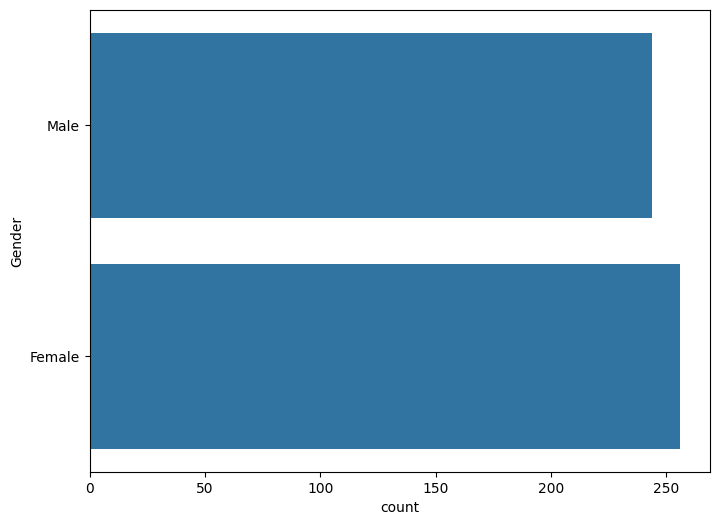

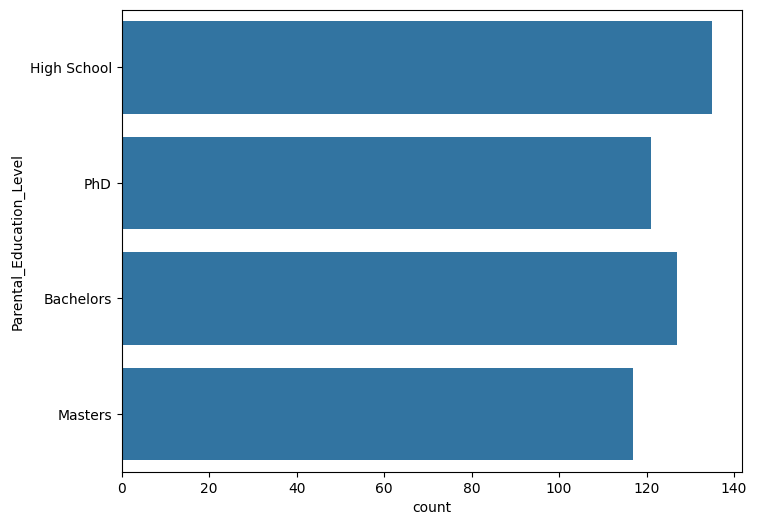

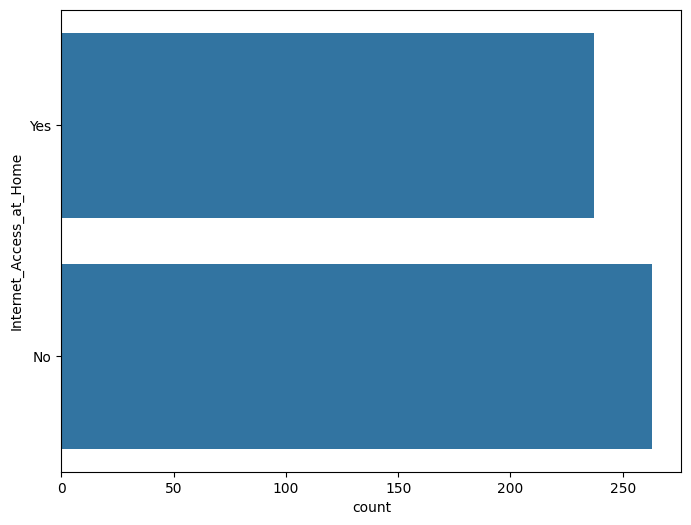

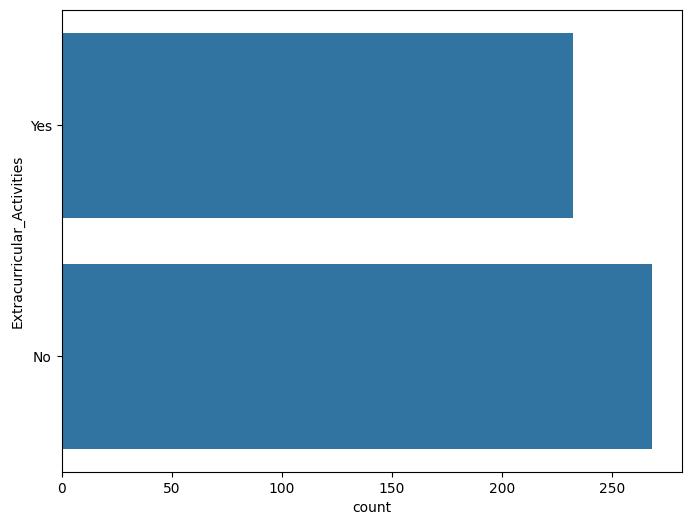

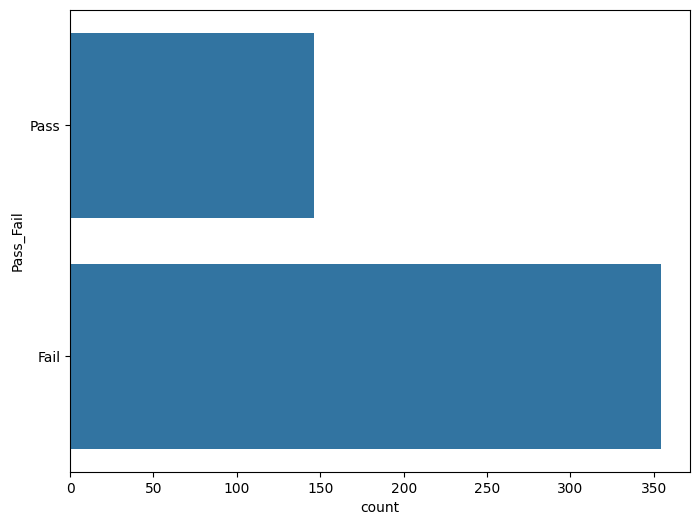

In [234]:
categorical_columns=['Gender', 'Parental_Education_Level','Internet_Access_at_Home', 'Extracurricular_Activities','Pass_Fail']
for col in categorical_columns:
  plt.figure(figsize=(8,6));
  sns.countplot(df[col])


<Axes: >

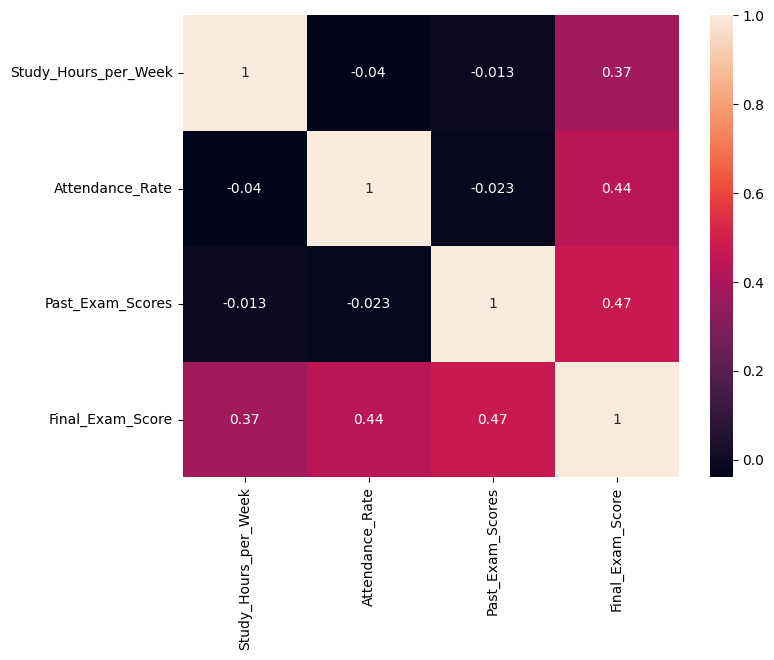

In [235]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data cleaning and preprocessing

In [236]:
df_cleaned=df.copy()

In [237]:
df_cleaned.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [238]:
df_cleaned.drop(columns=['Student_ID'], inplace=True)


In [239]:
df_cleaned['Parental_Education_Level'].unique()

array(['High School', 'PhD', 'Bachelors', 'Masters'], dtype=object)

In [240]:
categorical_columns=['Gender', 'Parental_Education_Level', 'Internet_Access_at_Home',
       'Extracurricular_Activities', 'Pass_Fail']

In [241]:
df_cleaned['Gender']=df_cleaned['Gender'].map({'Male':0,'Female':1})

In [242]:
df_cleaned['Internet_Access_at_Home']=df_cleaned['Internet_Access_at_Home'].map({'No':0,'Yes':1})

In [243]:
df_cleaned['Extracurricular_Activities']=df_cleaned['Extracurricular_Activities'].map({'No':0,'Yes':1})

In [244]:
df_cleaned['Pass_Fail']=df_cleaned['Pass_Fail'].map({'Fail':0,'Pass':1})

In [245]:
df_cleaned.rename(columns={
    'Gender':'is_female',
    'Internet_Access_at_Home':'has_internet',
    'Extracurricular_Activities':'has_extracurricular_activities',
    'Pass_Fail':'is_passed',
},inplace=True)

In [246]:
#One hot encoding
df_cleaned=pd.get_dummies(
      df_cleaned,
      columns=['Parental_Education_Level'],
      drop_first=True
  )

In [247]:
df_cleaned.head()

,is_female,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,has_internet,has_extracurricular_activities,Final_Exam_Score,is_passed,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD
0,0,31,68.267841,86,1,1,63,1,True,False,False
1,0,16,78.222927,73,0,0,50,0,False,False,True
2,1,21,87.525096,74,1,0,55,0,False,False,True
3,1,27,92.076483,99,0,0,65,1,False,False,False
4,1,37,98.655517,63,0,1,70,1,False,True,False


In [248]:
df_cleaned=df_cleaned.astype(int)

#Feature engineering

<Axes: xlabel='Attendance_Rate', ylabel='Count'>

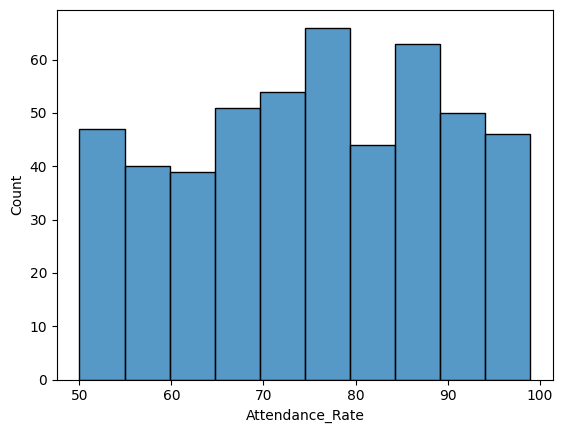

In [249]:
sns.histplot(df_cleaned['Attendance_Rate'])

In [250]:
df_cleaned.columns

Index(['is_female', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'has_internet', 'has_extracurricular_activities',
       'Final_Exam_Score', 'is_passed', 'Parental_Education_Level_High School',
       'Parental_Education_Level_Masters', 'Parental_Education_Level_PhD'],
      dtype='object')

In [251]:
df_cleaned.head()

,is_female,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,has_internet,has_extracurricular_activities,Final_Exam_Score,is_passed,Parental_Education_Level_High School,Parental_Education_Level_Masters,Parental_Education_Level_PhD
0,0,31,68,86,1,1,63,1,1,0,0
1,0,16,78,73,0,0,50,0,0,0,1
2,1,21,87,74,1,0,55,0,0,0,1
3,1,27,92,99,0,0,65,1,0,0,0
4,1,37,98,63,0,1,70,1,0,1,0


In [252]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [253]:
columns=[ 'Study_Hours_per_Week', 'Attendance_Rate','Past_Exam_Scores',]
df_cleaned[columns]=scaler.fit_transform(df_cleaned[columns])

In [254]:
from scipy.stats import pearsonr
correlations={
    feature:pearsonr(df_cleaned[feature],df_cleaned['Final_Exam_Score'])[0]
    for feature in columns
}
correlation_df=pd.DataFrame(list(correlations.items()),columns=['feature','Pearsonr Correlation'])
correlation_df.sort_values(by='Pearsonr Correlation',ascending=False)

,feature,Pearsonr Correlation
2,Past_Exam_Scores,0.474257
1,Attendance_Rate,0.435387
0,Study_Hours_per_Week,0.374708


In [255]:
df_cleaned.columns

Index(['is_female', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'has_internet', 'has_extracurricular_activities',
       'Final_Exam_Score', 'is_passed', 'Parental_Education_Level_High School',
       'Parental_Education_Level_Masters', 'Parental_Education_Level_PhD'],
      dtype='object')

In [256]:
df_cleaned.columns

Index(['is_female', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'has_internet', 'has_extracurricular_activities',
       'Final_Exam_Score', 'is_passed', 'Parental_Education_Level_High School',
       'Parental_Education_Level_Masters', 'Parental_Education_Level_PhD'],
      dtype='object')

In [257]:
from sklearn.model_selection import train_test_split

In [258]:
X=df_cleaned.drop(columns=['Final_Exam_Score'])
y=df_cleaned['Final_Exam_Score']

In [259]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [260]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()


In [261]:
model.fit(X_train,y_train)

LinearRegression()

In [262]:
y_pred=model.predict(X_test)

In [263]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(r2)

0.7764750882808535


In [264]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-(1-r2)*(n-1)/(n-p-1)
print(adjusted_r2)

0.7513599296607247
